<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karthickveerakumar/salary-data-simple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salary-data-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-data-simple-linear-regression


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

df = pd.read_csv(f"{path}/Salary_Data.csv")
print(df.head())
print(df.info())


   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


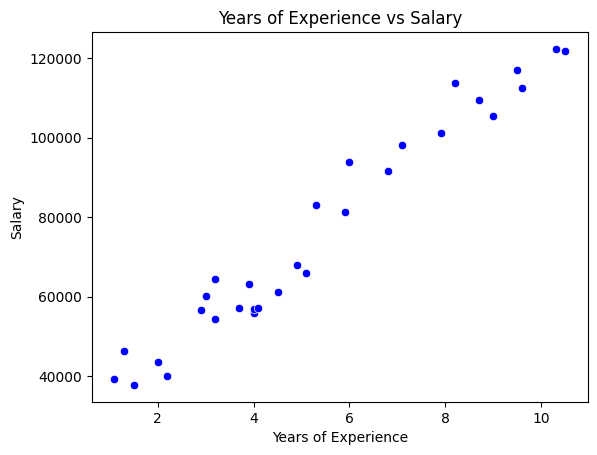

In [4]:
# Scatter plot
sns.scatterplot(x='YearsExperience', y='Salary', data=df, color='blue')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


In [5]:
X = df['YearsExperience'].values
y = df['Salary'].values

# Normalize for faster convergence
X = (X - np.mean(X)) / np.std(X)


In [6]:
# Hyperparameters
alpha = 0.01       # learning rate
epochs = 1000       # number of iterations
m = len(X)          # number of samples

# Initialize parameters
theta0 = 0
theta1 = 0

# To store loss
cost_history = []

# Gradient Descent Loop
for _ in range(epochs):
    y_pred = theta0 + theta1 * X
    error = y_pred - y
    cost = (1/(2*m)) * np.sum(error ** 2)
    cost_history.append(cost)

    # Gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Parameter update
    theta0 = theta0 - alpha * d_theta0
    theta1 = theta1 - alpha * d_theta1

print(f"Optimized parameters → θ0: {theta0:.2f}, θ1: {theta1:.2f}")


Optimized parameters → θ0: 75999.72, θ1: 26366.04


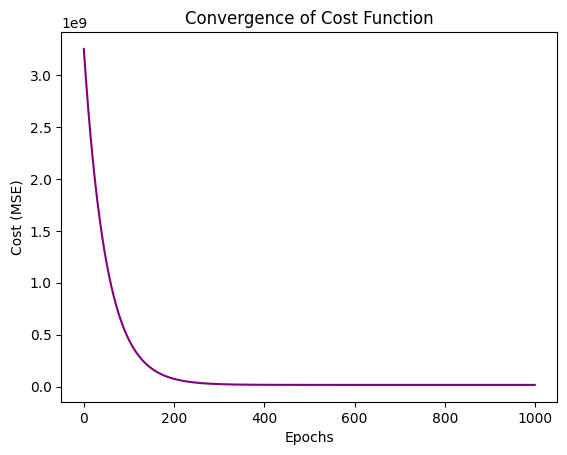

In [7]:
plt.plot(range(epochs), cost_history, color='purple')
plt.title("Convergence of Cost Function")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.show()


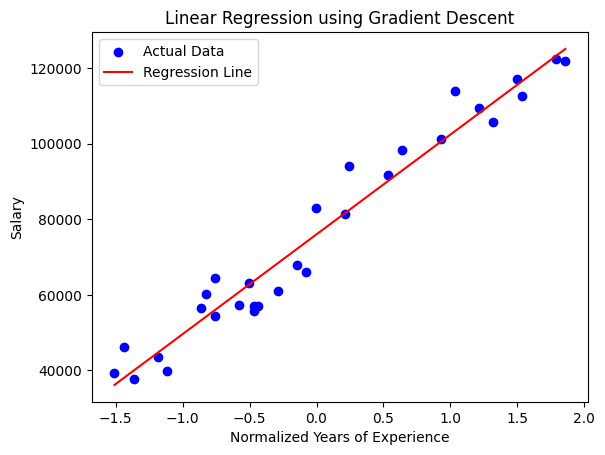

In [8]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, theta0 + theta1 * X, color='red', label='Regression Line')
plt.xlabel("Normalized Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.title("Linear Regression using Gradient Descent")
plt.show()


In [9]:
# Predict for a few samples
test_samples = np.array([-1, 0, 1])
predicted_salaries = theta0 + theta1 * test_samples
for i, val in enumerate(test_samples):
    print(f"YearsExperience (normalized): {val}, Predicted Salary: {predicted_salaries[i]:.2f}")


YearsExperience (normalized): -1, Predicted Salary: 49633.67
YearsExperience (normalized): 0, Predicted Salary: 75999.72
YearsExperience (normalized): 1, Predicted Salary: 102365.76
